<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/political_system_marl_colab_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MARL-моделирование политических систем — научно строгая версия (v2)

**Алгоритм:** MAPPO (Multi-Agent PPO) в схеме **CTDE** (centralized training, decentralized execution).
**Страны:** США, Франция, Германия, Россия, Япония, Индия, Китай.



| Что добавлено в v2 | Зачем |
|---|---|
| **Baselines** (random, heuristic, untrained) | объективная точка отсчёта: обученная политика должна их превосходить |
| **MAPPO** (GAE, clipped surrogate, KL early-stop, entropy, minibatch) | стабильная сходимость для дискретных действий |
| **Ранняя остановка + лучший чекпойнт** | избегаем деградации финальной политики, оцениваем лучшую |
| **Диагностика** (entropy, actor/critic loss, approx_kl, clip_frac, explained variance) | контроль качества обучения |
| **Мульти-сид** (5 сидов по умолчанию) | оценка устойчивости результатов (mean±std) |
| **Мягкая динамика среды** (soft bounds + гомеостаз) | индикаторы не упираются в 1.0, как в v1 |
| **Штраф за противоречия** | нереалистичные состояния (высокая легитимность при высоком неравенстве) штрафуются |
| **Архив результатов** (json/csv/xlsx/png/md/zip + загрузка) | воспроизводимость и выгрузка |

> Данные **синтетические и интерпретируемые**; реальные  источники не используются.


## 0. Зависимости и устройство

В Colab включите GPU: **Среда выполнения → Сменить среду выполнения → GPU**. Есть CPU fallback.

In [1]:
# При необходимости раскомментируйте:
# !pip -q install torch numpy pandas matplotlib seaborn tqdm openpyxl
import torch
print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128 | CUDA: True


## 1. Постановка и обоснование выбора алгоритма (MAPPO vs MADDPG/MATD3)

Каждая страна — частично наблюдаемая марковская игра: ролевые агенты (правительство, бюрократия, бизнес, медиа, силовики и др.) выбирают **дискретные** политические стратегии, а общее состояние страны эволюционирует.

**Почему MAPPO, а не MADDPG/MATD3:**

- Действия **дискретны** (политические стратегии). MADDPG/MATD3 ориентированы на непрерывные действия и требуют приёмов вроде Gumbel-softmax; для дискретного случая это менее естественно и стабильно.
- Нужен **централизованный критик** $V(s)$ для борьбы с нестационарностью среды при одновременном обучении агентов — это ядро CTDE и MAPPO.
- PPO даёт **clipped surrogate objective**, **GAE($\lambda$)**, **KL-раннюю остановку** и **энтропийную регуляризацию** — проверенный рецепт стабильной on-policy сходимости.
- Для скорости (5 сидов × 7 стран) используем **один общий актор на страну** с кодированием роли (one-hot), плюс централизованный критик $V(s)$. Это быстрее, чем отдельные сети на каждую роль, и сохраняет различие ролевых стратегий через вход роли.

**Целевая функция PPO (на агента):**
$$L^{CLIP}(\theta) = \mathbb{E}_t\big[\min(r_t(\theta)\hat{A}_t,\ \mathrm{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat{A}_t)\big],\quad r_t(\theta)=\frac{\pi_\theta(a_t|o_t)}{\pi_{\theta_{old}}(a_t|o_t)}.$$

**GAE($\lambda$):** $\hat{A}_t=\sum_{l\ge0}(\gamma\lambda)^l\delta_{t+l}$, где $\delta_t=r_t+\gamma V(s_{t+1})-V(s_t)$.

**Интерпретация компонентов RL** — как в политологии: актор = стратегия актора-роли; централизованный критик = аналитическая оценка «здоровья» политического режима; награда = устойчивость+развитие+адаптивность+легитимность+обратная связь за вычетом штрафов.

## 2. Устройство и воспроизводимость

In [2]:
"""Научно строгая версия MARL-эксперимента (v2). MAPPO/CTDE на PyTorch.
Мягкая динамика среды, штраф за противоречия, baselines, ранняя остановка,
лучший чекпойнт, диагностика обучения, мульти-сид. CPU/GPU fallback.

Этот файл — проверяемый исходник; идентичный код встраивается в notebook v2."""
import os
import json
import time
import math
import random
import zipfile
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- # 0. Устройство и воспроизводимость ---
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 3. Индикаторы состояния, роли и политические действия

11 индикаторов состояния, 11 ролей (подмножество на страну), 12 интерпретируемых политических действий (включая `economic_stimulus`, `security_measure`, `feedback` — нужны для эвристического baseline).

In [3]:
# --- # 1. Индикаторы, роли, действия ---
STATE_INDICATORS = [
    "economy", "social_trust", "legitimacy", "adaptivity", "inequality",
    "polarization", "external_pressure", "tech_modern", "feedback_quality",
    "admin_capacity", "innovation",
]
N_IND = len(STATE_INDICATORS)
IDX = {n: i for i, n in enumerate(STATE_INDICATORS)}

ROLE_CATALOG = [
    "executive", "bureaucracy", "legislature", "business", "civil",
    "media", "regional", "geopolitics", "judiciary", "security", "technocrats",
]
ROLE_IDX = {r: i for i, r in enumerate(ROLE_CATALOG)}

ACTION_CATALOG = [
    "redistribution",     # перераспределение
    "reform",             # институциональная реформа
    "regulation",         # регулирование / контроль
    "communication",      # коммуникация / легитимация
    "coalition",          # коалиция / компромисс
    "mobilization",       # мобилизация
    "innovation",         # инновационные проекты
    "foreign_response",   # внешнеполитическая реакция
    "economic_stimulus",  # экономический стимул
    "security_measure",   # меры безопасности / контроль
    "feedback",           # каналы обратной связи
    "status_quo",         # статус-кво
]
N_ACT = len(ACTION_CATALOG)
ACT = {a: i for i, a in enumerate(ACTION_CATALOG)}

## 4. Мягкие границы и гомеостаз (исправление насыщения из v1)

В v1 грубый `np.clip(state, 0, 1)` загонял индикаторы к 1.0. Здесь — **мягкое ограничение** в $[0.02, 0.98]$ через сжатый сигмоид, экстремумы недостижимы:
$$\mathrm{soft}(x) = 0.02 + 0.96\cdot\sigma\big(k(x-0.5)\big),\quad k=3.2.$$
Плюс **гомеостаз** (regression-to-mean): без действий индикаторы медленно возвращаются к 0.5. Это создаёт нетривиальную задачу управления и предотвращает массовое насыщение.

In [4]:
# --- # 2. Мягкие границы и гомеостаз ---
SOFT_LO, SOFT_HI = 0.02, 0.98


def soft_bound(x: np.ndarray) -> np.ndarray:
    """Мягкое ограничение в [SOFT_LO, SOFT_HI] без жёсткого упора в 0/1.
    Используем сжатый сигмоид вокруг текущего значения: значения у границ
    замедляются, экстремумы недостижимы. Линейно в середине диапазона."""
    # Преобразование: y = lo + (hi-lo) * sigmoid(k*(x-0.5)) даёт гладкое насыщение,
    # но мы хотим сохранить ~линейность в центре, поэтому k умеренный.
    k = 3.2
    y = SOFT_LO + (SOFT_HI - SOFT_LO) / (1.0 + np.exp(-k * (x - 0.5)))
    return y.astype(np.float32)

## 5. Конфигурации семи стран

Синтетические экспертные параметры: набор ролей, начальное состояние, веса награды (целевая функция режима), чувствительность к шокам, централизация.

In [5]:
# --- # 3. Конфигурация стран ---
@dataclass
class CountryConfig:
    name: str
    name_ru: str
    roles: List[str]
    init_state: Dict[str, float]
    reward_weights: Dict[str, float]
    shock_sensitivity: float = 1.0
    centralization: float = 0.5


def _w(**kw) -> Dict[str, float]:
    base = dict(stability=1.0, development=1.0, adaptivity=1.0,
                legitimacy=1.0, feedback=1.0)
    base.update(kw)
    return base


def build_country_configs() -> Dict[str, CountryConfig]:
    c: Dict[str, CountryConfig] = {}
    c["USA"] = CountryConfig(
        "USA", "США",
        ["executive", "legislature", "judiciary", "business", "media",
         "civil", "regional", "geopolitics"],
        dict(economy=0.66, social_trust=0.52, legitimacy=0.56, adaptivity=0.58,
             inequality=0.52, polarization=0.62, external_pressure=0.46,
             tech_modern=0.74, feedback_quality=0.56, admin_capacity=0.62,
             innovation=0.72),
        _w(development=1.15, legitimacy=1.05), 0.9, 0.35)
    c["France"] = CountryConfig(
        "France", "Франция",
        ["executive", "bureaucracy", "legislature", "business", "civil",
         "media", "geopolitics"],
        dict(economy=0.60, social_trust=0.48, legitimacy=0.52, adaptivity=0.54,
             inequality=0.44, polarization=0.54, external_pressure=0.42,
             tech_modern=0.68, feedback_quality=0.56, admin_capacity=0.68,
             innovation=0.62),
        _w(feedback=1.15, stability=1.05), 1.0, 0.6)
    c["Germany"] = CountryConfig(
        "Germany", "Германия",
        ["executive", "bureaucracy", "legislature", "business", "civil",
         "regional", "technocrats", "geopolitics"],
        dict(economy=0.68, social_trust=0.58, legitimacy=0.62, adaptivity=0.60,
             inequality=0.38, polarization=0.42, external_pressure=0.44,
             tech_modern=0.72, feedback_quality=0.64, admin_capacity=0.74,
             innovation=0.66),
        _w(stability=1.2, adaptivity=1.1), 0.85, 0.48)
    c["Russia"] = CountryConfig(
        "Russia", "Россия",
        ["executive", "bureaucracy", "security", "business", "regional",
         "media", "civil", "geopolitics"],
        dict(economy=0.54, social_trust=0.46, legitimacy=0.56, adaptivity=0.44,
             inequality=0.56, polarization=0.50, external_pressure=0.70,
             tech_modern=0.56, feedback_quality=0.40, admin_capacity=0.62,
             innovation=0.52),
        _w(stability=1.3, legitimacy=1.15, adaptivity=0.85), 1.1, 0.82)
    c["Japan"] = CountryConfig(
        "Japan", "Япония",
        ["executive", "bureaucracy", "legislature", "business", "civil",
         "technocrats", "geopolitics"],
        dict(economy=0.62, social_trust=0.60, legitimacy=0.60, adaptivity=0.52,
             inequality=0.40, polarization=0.36, external_pressure=0.52,
             tech_modern=0.78, feedback_quality=0.60, admin_capacity=0.76,
             innovation=0.66),
        _w(stability=1.15, development=1.1), 0.9, 0.56)
    c["India"] = CountryConfig(
        "India", "Индия",
        ["executive", "bureaucracy", "legislature", "judiciary", "business",
         "civil", "regional", "media", "geopolitics"],
        dict(economy=0.58, social_trust=0.50, legitimacy=0.54, adaptivity=0.52,
             inequality=0.62, polarization=0.56, external_pressure=0.48,
             tech_modern=0.54, feedback_quality=0.50, admin_capacity=0.48,
             innovation=0.60),
        _w(development=1.25, feedback=1.1), 1.05, 0.45)
    c["China"] = CountryConfig(
        "China", "Китай",
        ["executive", "bureaucracy", "security", "business", "regional",
         "technocrats", "civil", "geopolitics"],
        dict(economy=0.70, social_trust=0.54, legitimacy=0.58, adaptivity=0.54,
             inequality=0.52, polarization=0.40, external_pressure=0.64,
             tech_modern=0.72, feedback_quality=0.44, admin_capacity=0.78,
             innovation=0.70),
        _w(development=1.25, stability=1.2, feedback=0.9), 1.0, 0.85)
    return c

## 6. Шоки (масштаб уменьшен для более гладкой динамики)

In [6]:
# --- # 4. Шоки ---
SHOCK_TYPES = {
    "geopolitical":    {"external_pressure": +0.18, "economy": -0.04, "legitimacy": -0.02},
    "economic_crisis": {"economy": -0.18, "social_trust": -0.06, "inequality": +0.06},
    "polarization":    {"polarization": +0.18, "social_trust": -0.05, "legitimacy": -0.03},
    "tech_shock":      {"tech_modern": +0.12, "innovation": +0.10, "admin_capacity": -0.03},
    "trust_crisis":    {"social_trust": -0.15, "legitimacy": -0.12, "feedback_quality": -0.06},
}

## 7. Среда: динамика, метрики и награда со штрафом за противоречия

Переход: $s_{t+1}=\mathrm{soft}\big(s_t + \Delta_{actions} + N(s_t) + \text{noise} + \text{shock}\big)$.

**Штраф за противоречия** $\text{contra}(s)$ штрафует политически  нереалистичные комбинации:
- высокая легитимность/доверие при высоком неравенстве или поляризации;
- высокое развитие при слабой обратной связи/адаптивности;
- высокая стабильность при низкой легитимности или высоком внешнем давлении.

**Награда:** $r = \dfrac{\sum_k w_k m_k(s)}{\sum_k w_k} - 0.25\,\text{inequality} - 0.5\,\text{contra}(s)$.

Компоненты награды сохраняются в `info["components"]` для декомпозиции.

In [7]:
# --- # 5. Среда страны (мягкая динамика, гомеостаз, штраф за противоречия) ---
ACTION_EFFECTS = {
    "redistribution":   {"inequality": -0.060, "social_trust": +0.034, "economy": -0.018},
    "reform":           {"adaptivity": +0.058, "admin_capacity": +0.026, "legitimacy": -0.010,
                          "polarization": +0.016},
    "regulation":       {"admin_capacity": +0.036, "innovation": -0.022, "polarization": -0.016},
    "communication":    {"legitimacy": +0.034, "feedback_quality": +0.038, "social_trust": +0.022},
    "coalition":        {"polarization": -0.050, "legitimacy": +0.024, "adaptivity": +0.016},
    "mobilization":     {"polarization": +0.044, "social_trust": +0.016, "legitimacy": +0.008},
    "innovation":       {"innovation": +0.058, "tech_modern": +0.046, "economy": +0.030,
                          "inequality": +0.012},
    "foreign_response": {"external_pressure": -0.058, "economy": -0.012, "legitimacy": +0.012},
    "economic_stimulus":{"economy": +0.050, "inequality": +0.012, "admin_capacity": -0.008},
    "security_measure": {"polarization": -0.028, "admin_capacity": +0.024, "feedback_quality": -0.020},
    "feedback":         {"feedback_quality": +0.054, "adaptivity": +0.024, "legitimacy": +0.016},
    "status_quo":       {"adaptivity": -0.020, "economy": +0.008},
}

# Гомеостатические «якоря» (regression-to-mean) — куда тянется индикатор без действий.
HOMEOSTASIS_TARGET = 0.5
HOMEO_RATE = 0.008


class CountryEnv:
    def __init__(self, cfg: CountryConfig, horizon: int, seed: int):
        self.cfg = cfg
        self.horizon = horizon
        self.roles = cfg.roles
        self.n_agents = len(cfg.roles)
        self.rng = np.random.RandomState(seed)
        self.reset()

    def reset(self) -> np.ndarray:
        self.t = 0
        self.state = np.array([self.cfg.init_state[k] for k in STATE_INDICATORS],
                              dtype=np.float32)
        self.last_shock = ""
        return self.state.copy()

    def _apply_actions(self, actions: List[int]) -> np.ndarray:
        delta = np.zeros(N_IND, dtype=np.float32)
        for role, a in zip(self.roles, actions):
            name = ACTION_CATALOG[a]
            for ind, d in ACTION_EFFECTS[name].items():
                mult = 1.0
                if role == "business" and ind in ("economy", "innovation"):
                    mult = 1.4
                elif role == "security" and ind in ("polarization", "admin_capacity"):
                    mult = 1.4
                elif role == "technocrats" and ind in ("innovation", "tech_modern"):
                    mult = 1.4
                elif role == "civil" and ind in ("feedback_quality", "social_trust"):
                    mult = 1.3
                elif role == "media" and ind in ("feedback_quality", "polarization"):
                    mult = 1.3
                elif role == "geopolitics" and ind == "external_pressure":
                    mult = 1.5
                delta[IDX[ind]] += d * mult
        # нормируем вклад по числу агентов, чтобы крупные системы не «перегревались»,
        # но мягче, чем sqrt — иначе политика почти не влияет на состояние
        delta /= max(1.0, 0.5 * self.n_agents)
        return delta

    def _natural(self, s: np.ndarray) -> np.ndarray:
        n = np.zeros(N_IND, dtype=np.float32)
        n[IDX["economy"]] += 0.012 * (s[IDX["innovation"]] - 0.5)
        n[IDX["economy"]] -= 0.018 * (s[IDX["external_pressure"]] - 0.5)
        n[IDX["legitimacy"]] += 0.016 * (s[IDX["feedback_quality"]] - 0.5)
        n[IDX["legitimacy"]] -= 0.016 * (s[IDX["polarization"]] - 0.5)
        n[IDX["social_trust"]] += 0.014 * (s[IDX["legitimacy"]] - 0.5)
        n[IDX["adaptivity"]] += 0.008 * (s[IDX["innovation"]] - 0.5)
        n[IDX["polarization"]] += 0.008 * (s[IDX["inequality"]] - 0.5)
        n[IDX["external_pressure"]] -= 0.010
        cz = self.cfg.centralization
        n[IDX["polarization"]] -= 0.006 * cz
        n[IDX["feedback_quality"]] -= 0.006 * cz
        # гомеостаз: мягкое возвращение к 0.5
        n += HOMEO_RATE * (HOMEOSTASIS_TARGET - s)
        return n

    def step(self, actions: List[int]):
        s = self.state
        delta = self._apply_actions(actions)
        natural = self._natural(s)
        noise = self.rng.normal(0, 0.004, size=N_IND).astype(np.float32)
        raw = s + delta + natural + noise

        # шок
        self.last_shock = ""
        if self.rng.rand() < 0.05 * self.cfg.shock_sensitivity:
            st = self.rng.choice(list(SHOCK_TYPES.keys()))
            for ind, d in SHOCK_TYPES[st].items():
                raw[IDX[ind]] += d * self.cfg.shock_sensitivity
            self.last_shock = st

        self.state = soft_bound(raw)
        reward, comps = self._reward(self.state)
        self.t += 1
        done = self.t >= self.horizon
        return self.state.copy(), reward, done, {"shock": self.last_shock, "components": comps}

    # ---- метрики и награда ----
    @staticmethod
    def stability_index(s):
        return float(np.clip(0.5 * (1 - s[IDX["polarization"]])
                             + 0.25 * (1 - s[IDX["external_pressure"]])
                             + 0.25 * s[IDX["social_trust"]], 0, 1))

    @staticmethod
    def development_index(s):
        return float(np.clip(0.5 * s[IDX["economy"]] + 0.3 * s[IDX["tech_modern"]]
                             + 0.2 * s[IDX["innovation"]], 0, 1))

    @staticmethod
    def adaptivity_index(s):
        return float(np.clip(0.6 * s[IDX["adaptivity"]] + 0.4 * s[IDX["admin_capacity"]], 0, 1))

    @staticmethod
    def legitimacy_index(s):
        return float(np.clip(0.6 * s[IDX["legitimacy"]] + 0.4 * s[IDX["social_trust"]], 0, 1))

    @staticmethod
    def feedback_index(s):
        return float(np.clip(s[IDX["feedback_quality"]], 0, 1))

    def _contradiction_penalty(self, s) -> float:
        """Штраф за внутренне противоречивые состояния (политологически нереалистичные)."""
        relu = lambda x: x if x > 0 else 0.0
        p = 0.0
        # высокая легитимность/доверие при высоком неравенстве или поляризации
        p += relu(self.legitimacy_index(s) - 0.6) * relu(s[IDX["inequality"]] - 0.6) * 1.6
        p += relu(self.legitimacy_index(s) - 0.6) * relu(s[IDX["polarization"]] - 0.6) * 1.4
        # высокое развитие при слабой обратной связи/адаптивности
        p += relu(self.development_index(s) - 0.6) * relu(0.4 - s[IDX["feedback_quality"]]) * 1.4
        p += relu(self.development_index(s) - 0.6) * relu(0.4 - s[IDX["adaptivity"]]) * 1.2
        # высокая стабильность при низкой легитимности или высоком внешнем давлении
        p += relu(self.stability_index(s) - 0.6) * relu(0.4 - self.legitimacy_index(s)) * 1.5
        p += relu(self.stability_index(s) - 0.6) * relu(s[IDX["external_pressure"]] - 0.7) * 1.2
        return float(p)

    def _reward(self, s):
        w = self.cfg.reward_weights
        comps = dict(
            stability=self.stability_index(s),
            development=self.development_index(s),
            adaptivity=self.adaptivity_index(s),
            legitimacy=self.legitimacy_index(s),
            feedback=self.feedback_index(s),
        )
        wsum = sum(w.values())
        base = sum(w[k] * comps[k] for k in comps) / wsum
        ineq_pen = 0.25 * s[IDX["inequality"]]
        contra = self._contradiction_penalty(s)
        comps["inequality_penalty"] = float(ineq_pen)
        comps["contradiction_penalty"] = float(contra)
        # нормированная награда около [0,1] за вычетом штрафов
        reward = float(base - ineq_pen - 0.5 * contra)
        comps["base"] = float(base)
        comps["reward"] = reward
        return reward, comps

## 8. Baseline-политики

- **`RandomPolicy`** — равномерно случайные действия.
- **`HeuristicPolicy`** — политологически интерпретируемая: реагирует на состояние (высокое внешнее давление → security/foreign_response; высокая поляризация → coalition/communication; низкая экономика → economic_stimulus/reform; низкая обратная связь → feedback/communication; высокое неравенство → redistribution; иначе — микс развития/реформ).
- **untrained** — необученный актор MAPPO (greedy) как ещё одна точка отсчёта.

In [8]:
# --- # 6. Политики-baselines ---
class RandomPolicy:
    def __init__(self, env: CountryEnv, seed: int = 0):
        self.env = env
        self.rng = np.random.RandomState(seed)

    def act(self, state):
        return [int(self.rng.randint(N_ACT)) for _ in self.env.roles]


class HeuristicPolicy:
    """Политологически интерпретируемая эвристика на основе состояния."""
    def __init__(self, env: CountryEnv, seed: int = 0):
        self.env = env
        self.rng = np.random.RandomState(seed)

    def act(self, state):
        s = state
        acts = []
        for role in self.env.roles:
            if s[IDX["external_pressure"]] > 0.6:
                a = "foreign_response" if role == "geopolitics" else "security_measure"
            elif s[IDX["polarization"]] > 0.6:
                a = "coalition" if role in ("legislature", "executive") else "communication"
            elif s[IDX["economy"]] < 0.45:
                a = "economic_stimulus" if role in ("executive", "business") else "reform"
            elif s[IDX["feedback_quality"]] < 0.45:
                a = "feedback" if role in ("media", "civil") else "communication"
            elif s[IDX["inequality"]] > 0.6:
                a = "redistribution"
            else:
                a = self.rng.choice(["innovation", "reform", "communication", "coalition"])
            acts.append(ACT[a])
        return acts

## 9. MAPPO: shared actor (role embedding) + централизованный критик $V(s)$

- **`SharedActor`** — общий на страну; роль кодируется one-hot и подаётся вместе с состоянием.
- **`CentralCritic`** — оценивает $V(s)$ по глобальному состоянию страны.
- **`MAPPOTrainer`** — rollout buffer, GAE($\lambda$), нормализация наград (Welford) для устойчивого обучающего сигнала, PPO с клиппингом, value clipping, нормализация advantage, минибатчи, несколько PPO-эпох, **KL-ранняя остановка** внутри обновления, клиппинг градиентов, энтропийная регуляризация. Диагностика: actor/critic loss, entropy, approx_kl, clip_fraction, explained variance.

> Нормализация наград критична: без неё плотная награда ~16 с малой дисперсией делает преимущества шумом, и политика деградирует). С бегущей нормализацией обученная политика устойчиво превосходит baseline.

In [9]:
# --- # 7. MAPPO: shared actor (role embedding) + centralized critic V(s) ---
class SharedActor(nn.Module):
    """Один актор на страну; роль кодируется one-hot и конкатенируется к состоянию."""
    def __init__(self, state_dim: int, n_roles: int, n_actions: int, hidden: int = 96):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + n_roles, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, obs):
        return self.net(obs)


class CentralCritic(nn.Module):
    def __init__(self, state_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, s):
        return self.net(s).squeeze(-1)


@dataclass
class PPOConfig:
    episodes: int = 600
    horizon: int = 40
    gamma: float = 0.98
    gae_lambda: float = 0.95
    clip_eps: float = 0.2
    ppo_epochs: int = 4
    minibatches: int = 4
    lr: float = 1.5e-3
    entropy_coef: float = 0.01
    value_coef: float = 0.5
    max_grad_norm: float = 0.5
    target_kl: float = 0.03
    value_clip: float = 0.2
    hidden: int = 96
    # ранняя остановка
    es_window: int = 50
    es_patience: int = 20
    es_min_delta: float = 0.002
    eval_episodes: int = 20


class RolloutBuffer:
    def __init__(self):
        self.clear()

    def clear(self):
        self.obs = []          # [T, n_agents, obs_dim]
        self.global_s = []     # [T, state_dim]
        self.actions = []      # [T, n_agents]
        self.logps = []        # [T, n_agents]
        self.rewards = []      # [T]
        self.values = []       # [T]
        self.dones = []        # [T]


class MAPPOTrainer:
    def __init__(self, cfg: CountryConfig, ppo: PPOConfig, device, seed: int):
        self.cfg = cfg
        self.ppo = ppo
        self.device = device
        self.seed = seed
        self.env = CountryEnv(cfg, ppo.horizon, seed)
        self.n_roles = len(cfg.roles)
        self.state_dim = N_IND
        self.obs_dim = N_IND + self.n_roles
        self.actor = SharedActor(self.state_dim, self.n_roles, N_ACT, ppo.hidden).to(device)
        self.critic = CentralCritic(self.state_dim, ppo.hidden + 32).to(device)
        self.opt = torch.optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()), lr=ppo.lr)
        # role one-hot матрица
        self.role_onehot = torch.eye(self.n_roles, device=device)
        # бегущие статистики наград для нормализации обучающего сигнала (Welford)
        self._r_n = 0
        self._r_mean = 0.0
        self._r_M2 = 0.0

    def _norm_rewards(self, rewards):
        for r in rewards:
            self._r_n += 1
            d = r - self._r_mean
            self._r_mean += d / self._r_n
            self._r_M2 += d * (r - self._r_mean)
        std = math.sqrt(self._r_M2 / self._r_n) if self._r_n > 1 else 1.0
        std = max(std, 1e-4)
        return [(r - self._r_mean) / std for r in rewards]

    def _obs_batch(self, state_np):
        s = torch.tensor(state_np, dtype=torch.float32, device=self.device)
        s_rep = s.unsqueeze(0).expand(self.n_roles, -1)
        return torch.cat([s_rep, self.role_onehot], dim=1)  # [n_roles, obs_dim]

    @torch.no_grad()
    def _policy(self, state_np):
        obs = self._obs_batch(state_np)
        logits = self.actor(obs)
        dist = torch.distributions.Categorical(logits=logits)
        a = dist.sample()
        logp = dist.log_prob(a)
        v = self.critic(torch.tensor(state_np, dtype=torch.float32,
                                     device=self.device).unsqueeze(0))
        return a, logp, v.squeeze(0)

    def collect_episode(self, buf: RolloutBuffer):
        state = self.env.reset()
        ep_reward = 0.0
        comps_accum = None
        while True:
            a, logp, v = self._policy(state)
            ns, r, done, info = self.env.step(a.tolist())
            buf.obs.append(self._obs_batch(state).cpu())
            buf.global_s.append(torch.tensor(state, dtype=torch.float32))
            buf.actions.append(a.cpu())
            buf.logps.append(logp.cpu())
            buf.rewards.append(r)
            buf.values.append(float(v.item()))
            buf.dones.append(float(done))
            ep_reward += r
            c = info["components"]
            comps_accum = c if comps_accum is None else {k: comps_accum[k] + c[k] for k in c}
            state = ns
            if done:
                break
        T = len(buf.rewards)
        comps_mean = {k: comps_accum[k] / T for k in comps_accum}
        return ep_reward, comps_mean

    def _gae(self, rewards, values, dones):
        T = len(rewards)
        adv = np.zeros(T, dtype=np.float32)
        last = 0.0
        for t in reversed(range(T)):
            next_v = 0.0 if (t == T - 1 or dones[t]) else values[t + 1]
            delta = rewards[t] + self.ppo.gamma * next_v * (1 - dones[t]) - values[t]
            last = delta + self.ppo.gamma * self.ppo.gae_lambda * (1 - dones[t]) * last
            adv[t] = last
        ret = adv + np.array(values, dtype=np.float32)
        return adv, ret

    def update(self, buf: RolloutBuffer):
        T = len(buf.rewards)
        obs = torch.stack(buf.obs).to(self.device)              # [T, n_roles, obs_dim]
        gs = torch.stack(buf.global_s).to(self.device)          # [T, state_dim]
        actions = torch.stack(buf.actions).to(self.device)      # [T, n_roles]
        old_logps = torch.stack(buf.logps).to(self.device)      # [T, n_roles]
        old_values = torch.tensor(buf.values, dtype=torch.float32, device=self.device)

        norm_rewards = self._norm_rewards(buf.rewards)
        adv, ret = self._gae(norm_rewards, buf.values, buf.dones)
        adv_t = torch.tensor(adv, device=self.device)
        ret_t = torch.tensor(ret, device=self.device)
        adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)

        idx = np.arange(T)
        mb_size = max(1, T // self.ppo.minibatches)
        diag = dict(actor_loss=[], critic_loss=[], entropy=[], approx_kl=[], clip_frac=[])
        stop = False
        for epoch in range(self.ppo.ppo_epochs):
            np.random.shuffle(idx)
            for start in range(0, T, mb_size):
                mb = idx[start:start + mb_size]
                mb_t = torch.tensor(mb, device=self.device, dtype=torch.long)
                o = obs[mb_t]                       # [b, n_roles, obs]
                logits = self.actor(o)
                dist = torch.distributions.Categorical(logits=logits)
                logp = dist.log_prob(actions[mb_t])             # [b, n_roles]
                ent = dist.entropy().mean()
                # advantage broadcast по агентам (общий командный advantage)
                a_mb = adv_t[mb_t].unsqueeze(1)
                ratio = torch.exp(logp - old_logps[mb_t])
                surr1 = ratio * a_mb
                surr2 = torch.clamp(ratio, 1 - self.ppo.clip_eps, 1 + self.ppo.clip_eps) * a_mb
                actor_loss = -torch.min(surr1, surr2).mean()

                v = self.critic(gs[mb_t])
                v_clipped = old_values[mb_t] + torch.clamp(
                    v - old_values[mb_t], -self.ppo.value_clip, self.ppo.value_clip)
                vl1 = (v - ret_t[mb_t]) ** 2
                vl2 = (v_clipped - ret_t[mb_t]) ** 2
                critic_loss = 0.5 * torch.max(vl1, vl2).mean()

                loss = actor_loss + self.ppo.value_coef * critic_loss - self.ppo.entropy_coef * ent
                self.opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    list(self.actor.parameters()) + list(self.critic.parameters()),
                    self.ppo.max_grad_norm)
                self.opt.step()

                with torch.no_grad():
                    approx_kl = (old_logps[mb_t] - logp).mean().item()
                    clip_frac = ((ratio - 1.0).abs() > self.ppo.clip_eps).float().mean().item()
                diag["actor_loss"].append(actor_loss.item())
                diag["critic_loss"].append(critic_loss.item())
                diag["entropy"].append(ent.item())
                diag["approx_kl"].append(approx_kl)
                diag["clip_frac"].append(clip_frac)
            if abs(np.mean(diag["approx_kl"][-self.ppo.minibatches:])) > self.ppo.target_kl:
                stop = True
                break

        # explained variance критика
        with torch.no_grad():
            v_all = self.critic(gs)
            ev = 1.0 - (ret_t - v_all).var() / (ret_t.var() + 1e-8)
        out = {k: float(np.mean(v)) for k, v in diag.items()}
        out["explained_variance"] = float(ev.item())
        out["kl_early_stop"] = stop
        return out

    @torch.no_grad()
    def evaluate(self, n_episodes: int, greedy: bool = True):
        rewards, final_states, comps_list = [], [], []
        for ep in range(n_episodes):
            state = self.env.reset()
            ep_r = 0.0
            comps_accum = None
            while True:
                obs = self._obs_batch(state)
                logits = self.actor(obs)
                if greedy:
                    a = logits.argmax(dim=-1)
                else:
                    a = torch.distributions.Categorical(logits=logits).sample()
                ns, r, done, info = self.env.step(a.tolist())
                ep_r += r
                c = info["components"]
                comps_accum = c if comps_accum is None else {k: comps_accum[k] + c[k] for k in c}
                state = ns
                if done:
                    break
            rewards.append(ep_r)
            final_states.append(self.env.state.copy())
            T = self.env.horizon
            comps_list.append({k: comps_accum[k] / T for k in comps_accum})
        S = np.mean(np.stack(final_states), axis=0)
        agg_comps = {k: float(np.mean([c[k] for c in comps_list])) for k in comps_list[0]}
        return {
            "mean_reward": float(np.mean(rewards)),
            "std_reward": float(np.std(rewards)),
            "final_state": S,
            "stability": CountryEnv.stability_index(S),
            "development": CountryEnv.development_index(S),
            "adaptation": CountryEnv.adaptivity_index(S),
            "legitimacy": CountryEnv.legitimacy_index(S),
            "feedback": CountryEnv.feedback_index(S),
            "components": agg_comps,
        }

    def get_state_dict(self):
        return {"actor": {k: v.cpu().clone() for k, v in self.actor.state_dict().items()},
                "critic": {k: v.cpu().clone() for k, v in self.critic.state_dict().items()}}

    def load_state_dict(self, sd):
        self.actor.load_state_dict(sd["actor"])
        self.critic.load_state_dict(sd["critic"])

## 10. Обучение: ранняя остановка, лучший чекпойнт, диагностика

In [10]:
# --- # 8. Обучение с ранней остановкой, лучшим чекпойнтом и диагностикой ---
def rolling_mean(x, w):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return np.array([np.mean(x[:i + 1]) for i in range(len(x))])
    return np.convolve(x, np.ones(w) / w, mode="valid")


def train_one(cfg: CountryConfig, ppo: PPOConfig, device, seed: int, progress=None):
    set_seed(seed)
    tr = MAPPOTrainer(cfg, ppo, device, seed)
    hist = {"reward": [], "rolling_reward": [], "entropy": [], "actor_loss": [],
            "critic_loss": [], "approx_kl": [], "clip_frac": [], "explained_variance": []}
    best_reward = -1e9
    best_episode = -1
    best_sd = tr.get_state_dict()
    patience_left = ppo.es_patience
    best_rolling = -1e9
    stopped_early = False
    stop_reason = "max_episodes"

    for ep in range(ppo.episodes):
        buf = RolloutBuffer()
        ep_r, _ = tr.collect_episode(buf)
        diag = tr.update(buf)
        hist["reward"].append(ep_r)
        for k in ["entropy", "actor_loss", "critic_loss", "approx_kl",
                  "clip_frac", "explained_variance"]:
            hist[k].append(diag[k])
        rr = float(np.mean(hist["reward"][-ppo.es_window:]))
        hist["rolling_reward"].append(rr)

        if ep_r > best_reward:
            best_reward = ep_r
            best_episode = ep
            best_sd = tr.get_state_dict()

        # ранняя остановка по rolling reward
        if rr > best_rolling + ppo.es_min_delta:
            best_rolling = rr
            patience_left = ppo.es_patience
        else:
            patience_left -= 1
            if patience_left <= 0 and ep >= ppo.es_window:
                stopped_early = True
                stop_reason = "early_stopping_plateau"
                break
        if progress is not None:
            progress.update(1)

    # загрузить лучший чекпойнт
    tr.load_state_dict(best_sd)
    return tr, hist, {
        "best_episode": int(best_episode),
        "best_reward": float(best_reward),
        "best_rolling_reward": float(best_rolling),
        "stopped_early": bool(stopped_early),
        "stop_reason": stop_reason,
        "episodes_run": len(hist["reward"]),
    }, best_sd

## 11. Диагностика сходимости

`late_slope` (наклон поздней части кривой), `late_cv` (коэффициент вариации), `improvement_over_baseline`, `best_vs_final_gap`, `stable_plateau`, итоговый флаг `converged`.

In [11]:
# --- # 9. Диагностика сходимости ---
def convergence_diagnostics(hist, train_meta, trained_reward, baseline_reward):
    rr = np.array(hist["rolling_reward"], dtype=float)
    n = len(rr)
    late = rr[max(0, n - 30):]
    if len(late) >= 2:
        xs = np.arange(len(late))
        late_slope = float(np.polyfit(xs, late, 1)[0])
        late_cv = float(np.std(late) / (abs(np.mean(late)) + 1e-8))
    else:
        late_slope, late_cv = 0.0, 0.0
    improvement = float(trained_reward - baseline_reward)
    best_vs_final = float(train_meta["best_reward"] - (hist["reward"][-1] if hist["reward"] else 0.0))
    stable_plateau = bool(abs(late_slope) < 0.01 and late_cv < 0.15)
    converged = bool(improvement > 0.0 and stable_plateau and len(rr) >= 10)
    return {
        "late_slope": late_slope,
        "late_cv": late_cv,
        "improvement_over_baseline": improvement,
        "best_vs_final_gap": best_vs_final,
        "stable_plateau": stable_plateau,
        "converged": converged,
    }

## 12. Оценка baseline-политик

In [12]:
# --- # 10. Baseline-оценка ---
def evaluate_policy(policy, env: CountryEnv, n_episodes: int):
    rewards, final_states = [], []
    for _ in range(n_episodes):
        state = env.reset()
        ep_r = 0.0
        while True:
            a = policy.act(state)
            ns, r, done, info = env.step(a)
            ep_r += r
            state = ns
            if done:
                break
        rewards.append(ep_r)
        final_states.append(env.state.copy())
    S = np.mean(np.stack(final_states), axis=0)
    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "final_state": S,
        "stability": CountryEnv.stability_index(S),
        "development": CountryEnv.development_index(S),
        "adaptation": CountryEnv.adaptivity_index(S),
        "legitimacy": CountryEnv.legitimacy_index(S),
        "feedback": CountryEnv.feedback_index(S),
    }

## 13. Полный эксперимент: страны × сиды, режимы SMOKE/DEFAULT/STRONG, прогресс-бары

In [13]:
# --- # 11. Полный эксперимент по странам и сидам ---
@dataclass
class ExperimentConfig:
    mode: str = "DEFAULT"
    seeds: List[int] = field(default_factory=lambda: [11, 22, 33, 44, 55])
    countries: List[str] = field(default_factory=lambda: list(build_country_configs().keys()))
    ppo: PPOConfig = field(default_factory=PPOConfig)


def make_mode(mode: str) -> ExperimentConfig:
    if mode == "SMOKE":
        return ExperimentConfig("SMOKE", [11], ["USA", "Germany"],
                                PPOConfig(episodes=120, horizon=30, es_window=20,
                                          es_patience=15, eval_episodes=10))
    if mode == "STRONG":
        return ExperimentConfig("STRONG", [11, 22, 33, 44, 55],
                                list(build_country_configs().keys()),
                                PPOConfig(episodes=1200, horizon=60, es_window=40,
                                          es_patience=12, eval_episodes=30))
    return ExperimentConfig("DEFAULT", [11, 22, 33, 44, 55],
                            list(build_country_configs().keys()),
                            PPOConfig(episodes=600, horizon=40, es_window=30,
                                      es_patience=8, eval_episodes=20))


def run_experiment(exp: ExperimentConfig, tqdm_fn=None, verbose=True):
    device = get_device()
    cfgs = build_country_configs()
    results = {"meta": {"device": str(device), "mode": exp.mode,
                        "seeds": exp.seeds, "countries": exp.countries},
               "per_run": {}, "best_checkpoints": {}}
    t0 = time.time()
    total_runs = len(exp.countries) * len(exp.seeds)
    run_i = 0
    for name in exp.countries:
        cfg = cfgs[name]
        results["per_run"][name] = {}
        results["best_checkpoints"][name] = {}
        for seed in exp.seeds:
            run_i += 1
            rt0 = time.time()
            # прогресс-бар по эпизодам
            prog = None
            if tqdm_fn is not None:
                prog = tqdm_fn(total=exp.ppo.episodes,
                               desc=f"{cfg.name_ru} seed={seed} [{run_i}/{total_runs}]",
                               leave=False)
            tr, hist, meta, best_sd = train_one(cfg, exp.ppo, device, seed, progress=prog)
            if prog is not None:
                prog.close()
            trained_eval = tr.evaluate(exp.ppo.eval_episodes, greedy=True)

            # baselines на той же среде/сидe
            env_b = CountryEnv(cfg, exp.ppo.horizon, seed + 10000)
            rnd = evaluate_policy(RandomPolicy(env_b, seed), env_b, exp.ppo.eval_episodes)
            heu = evaluate_policy(HeuristicPolicy(env_b, seed), env_b, exp.ppo.eval_episodes)
            # untrained: свежий актор без обучения
            untr = MAPPOTrainer(cfg, exp.ppo, device, seed + 999)
            untrained_eval = untr.evaluate(exp.ppo.eval_episodes, greedy=True)

            conv = convergence_diagnostics(hist, meta, trained_eval["mean_reward"],
                                           heu["mean_reward"])
            elapsed = time.time() - rt0
            results["per_run"][name][seed] = {
                "history": hist,
                "train_meta": meta,
                "trained": trained_eval,
                "baseline_random": rnd,
                "baseline_heuristic": heu,
                "baseline_untrained": untrained_eval,
                "convergence": conv,
                "elapsed_sec": elapsed,
            }
            results["best_checkpoints"][name][seed] = best_sd
            if verbose:
                print(f"  [{cfg.name_ru} seed={seed}] trained={trained_eval['mean_reward']:.3f} "
                      f"heur={heu['mean_reward']:.3f} rand={rnd['mean_reward']:.3f} "
                      f"conv={conv['converged']} early={meta['stopped_early']} "
                      f"({elapsed:.1f}s)")
    results["meta"]["total_elapsed_min"] = (time.time() - t0) / 60.0
    return results

## 14. Визуализация, агрегация по сидам и архив результатов

matplotlib/seaborn, агрегаты mean±std, markdown-таблицы без зависимости `tabulate`, полный архив (json/csv/xlsx/png/md/zip + чекпойнты).

In [14]:
import os
import io
import json
import zipfile
import datetime
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
RU = {c: cfg.name_ru for c, cfg in build_country_configs().items()}
METRIC_RU = {"stability": "Устойчивость", "development": "Развитие",
             "adaptation": "Адаптивность", "legitimacy": "Легитимность",
             "feedback": "Обр. связь"}


def df_to_md(df: pd.DataFrame) -> str:
    """Markdown-таблица без внешней зависимости tabulate."""
    idx_name = df.index.name or ""
    header = "| " + " | ".join([idx_name] + [str(c) for c in df.columns]) + " |"
    sep = "| " + " | ".join(["---"] * (len(df.columns) + 1)) + " |"
    lines = [header, sep]
    for idx, row in df.iterrows():
        lines.append("| " + " | ".join([str(idx)] + [str(v) for v in row.values]) + " |")
    return "\n".join(lines)


# ---------------------- агрегаты по сидам ----------------------
def aggregate(results) -> pd.DataFrame:
    rows = []
    for country, per_seed in results["per_run"].items():
        for metric_key, store_key in [("trained", "trained"),
                                      ("heuristic", "baseline_heuristic"),
                                      ("random", "baseline_random"),
                                      ("untrained", "baseline_untrained")]:
            vals = {m: [] for m in ["mean_reward", "stability", "development",
                                    "adaptation", "legitimacy", "feedback"]}
            for seed, run in per_seed.items():
                ev = run[store_key]
                for m in vals:
                    vals[m].append(ev[m])
            row = {"Страна": RU[country], "Политика": metric_key}
            for m in vals:
                row[m + "_mean"] = float(np.mean(vals[m]))
                row[m + "_std"] = float(np.std(vals[m]))
            rows.append(row)
    return pd.DataFrame(rows)


def metrics_table_meanstd(results) -> pd.DataFrame:
    """Таблица trained-метрик mean±std по странам (агрегирование по сидам)."""
    rows = []
    for country, per_seed in results["per_run"].items():
        acc = {m: [] for m in ["mean_reward", "stability", "development",
                               "adaptation", "legitimacy", "feedback"]}
        for seed, run in per_seed.items():
            for m in acc:
                acc[m].append(run["trained"][m])
        fmt = lambda m: f"{np.mean(acc[m]):.3f}±{np.std(acc[m]):.3f}"
        rows.append({"Страна": RU[country],
                     "Награда": fmt("mean_reward"),
                     "Устойчивость": fmt("stability"),
                     "Развитие": fmt("development"),
                     "Адаптивность": fmt("adaptation"),
                     "Легитимность": fmt("legitimacy"),
                     "Обр.связь": fmt("feedback")})
    return pd.DataFrame(rows).set_index("Страна")


def convergence_table(results) -> pd.DataFrame:
    rows = []
    for country, per_seed in results["per_run"].items():
        conv_flags, impr, slope, gap, early = [], [], [], [], []
        for seed, run in per_seed.items():
            c = run["convergence"]
            conv_flags.append(c["converged"])
            impr.append(c["improvement_over_baseline"])
            slope.append(c["late_slope"])
            gap.append(c["best_vs_final_gap"])
            early.append(run["train_meta"]["stopped_early"])
        rows.append({
            "Страна": RU[country],
            "Сошлось (доля сидов)": f"{np.mean(conv_flags):.2f}",
            "Δ над эвристикой": f"{np.mean(impr):.3f}",
            "late_slope": f"{np.mean(slope):.4f}",
            "best−final gap": f"{np.mean(gap):.3f}",
            "ранняя остановка": f"{np.mean(early):.2f}",
        })
    return pd.DataFrame(rows).set_index("Страна")


# ---------------------- графики ----------------------
def fig_reward_curves(results):
    fig, ax = plt.subplots(figsize=(11, 5))
    for country, per_seed in results["per_run"].items():
        curves = []
        for seed, run in per_seed.items():
            rr = rolling_mean(run["history"]["reward"], 10)
            curves.append(rr)
        L = min(len(c) for c in curves)
        arr = np.stack([c[:L] for c in curves])
        m, s = arr.mean(0), arr.std(0)
        x = np.arange(L)
        line, = ax.plot(x, m, linewidth=2, label=RU[country])
        ax.fill_between(x, m - s, m + s, alpha=0.12, color=line.get_color())
    ax.set_title("Кривые награды (скользящее среднее, mean±std по сидам)")
    ax.set_xlabel("Эпизод"); ax.set_ylabel("Награда за эпизод")
    ax.legend(ncol=4, fontsize=9)
    plt.tight_layout()
    return fig


def fig_trained_vs_baselines(results):
    agg = aggregate(results)
    countries = [RU[c] for c in results["per_run"].keys()]
    policies = ["trained", "heuristic", "random", "untrained"]
    labels = {"trained": "Обученная (MAPPO)", "heuristic": "Эвристика",
              "random": "Случайная", "untrained": "Необученная"}
    fig, ax = plt.subplots(figsize=(12, 6))
    width = 0.2
    x = np.arange(len(countries))
    for i, pol in enumerate(policies):
        sub = agg[agg["Политика"] == pol].set_index("Страна").reindex(countries)
        ax.bar(x + (i - 1.5) * width, sub["mean_reward_mean"], width,
               yerr=sub["mean_reward_std"], capsize=3, label=labels[pol])
    ax.set_xticks(x); ax.set_xticklabels(countries)
    ax.set_title("Обученная политика против baseline (средняя награда, mean±std)")
    ax.set_ylabel("Награда"); ax.legend(ncol=4, fontsize=9)
    plt.tight_layout()
    return fig


def fig_convergence_heatmap(results):
    metrics = ["converged", "improvement_over_baseline", "late_slope",
               "late_cv", "best_vs_final_gap"]
    labels = ["Сошлось", "Δ baseline", "late_slope", "late_cv", "best−final"]
    data = []
    countries = []
    for country, per_seed in results["per_run"].items():
        countries.append(RU[country])
        row = []
        for m in metrics:
            vals = [run["convergence"][m] for run in per_seed.values()]
            row.append(float(np.mean([float(v) for v in vals])))
        data.append(row)
    df = pd.DataFrame(data, index=countries, columns=labels)
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.heatmap(df, annot=True, fmt=".3f", cmap="RdYlGn", center=0, ax=ax)
    ax.set_title("Диагностика сходимости (среднее по сидам)")
    plt.tight_layout()
    return fig


def fig_entropy_loss(results):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for country, per_seed in results["per_run"].items():
        for key, ax, title in [("entropy", axes[0], "Энтропия политики"),
                               ("actor_loss", axes[1], "Actor loss"),
                               ("critic_loss", axes[2], "Critic loss")]:
            curves = [run["history"][key] for run in per_seed.values()]
            L = min(len(c) for c in curves)
            m = np.stack([c[:L] for c in curves]).mean(0)
            ax.plot(rolling_mean(m, 5), label=RU[country], linewidth=1.6)
            ax.set_title(title); ax.set_xlabel("Эпизод")
    axes[0].legend(ncol=2, fontsize=8)
    plt.tight_layout()
    return fig


def fig_final_state_heatmap(results):
    countries, data = [], []
    for country, per_seed in results["per_run"].items():
        countries.append(RU[country])
        states = [run["trained"]["final_state"] for run in per_seed.values()]
        data.append(np.mean(np.stack(states), 0))
    df = pd.DataFrame(np.array(data), index=countries, columns=STATE_INDICATORS)
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.heatmap(df, annot=True, fmt=".2f", cmap="viridis", ax=ax,
                cbar_kws={"label": "значение [0..1]"})
    ax.set_title("Финальные индикаторы обученной политики (среднее по сидам)")
    plt.tight_layout()
    return fig, df


def fig_radar(results):
    metrics = ["stability", "development", "adaptation", "legitimacy", "feedback"]
    labels = [METRIC_RU[m] for m in metrics]
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for country, per_seed in results["per_run"].items():
        vals = [np.mean([run["trained"][m] for run in per_seed.values()]) for m in metrics]
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=RU[country])
        ax.fill(angles, vals, alpha=0.05)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, fontsize=10)
    ax.set_title("Профили обученных политических систем", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.1), fontsize=9)
    plt.tight_layout()
    return fig


# ---------------------- архив результатов ----------------------
def build_archive(results, out_dir="results_v2"):
    os.makedirs(out_dir, exist_ok=True)
    fig_dir = os.path.join(out_dir, "figures")
    ckpt_dir = os.path.join(out_dir, "checkpoints")
    os.makedirs(fig_dir, exist_ok=True)
    os.makedirs(ckpt_dir, exist_ok=True)
    stamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")

    # 1) сводные таблицы
    tbl = metrics_table_meanstd(results)
    conv = convergence_table(results)
    agg = aggregate(results)
    tbl.to_csv(os.path.join(out_dir, "metrics_meanstd.csv"), encoding="utf-8")
    conv.to_csv(os.path.join(out_dir, "convergence.csv"), encoding="utf-8")
    agg.to_csv(os.path.join(out_dir, "aggregate_long.csv"), index=False, encoding="utf-8")
    try:
        with pd.ExcelWriter(os.path.join(out_dir, "results_v2.xlsx")) as xw:
            tbl.to_excel(xw, sheet_name="metrics")
            conv.to_excel(xw, sheet_name="convergence")
            agg.to_excel(xw, sheet_name="aggregate", index=False)
    except Exception as e:
        print("xlsx пропущен:", e)

    # 2) raw json (без тяжёлых тензоров чекпойнтов)
    raw = {"meta": results["meta"], "per_run": {}}
    for country, per_seed in results["per_run"].items():
        raw["per_run"][country] = {}
        for seed, run in per_seed.items():
            raw["per_run"][country][str(seed)] = {
                "train_meta": run["train_meta"],
                "convergence": run["convergence"],
                "trained": {k: (v.tolist() if isinstance(v, np.ndarray) else v)
                            for k, v in run["trained"].items() if k != "components"},
                "baseline_heuristic_reward": run["baseline_heuristic"]["mean_reward"],
                "baseline_random_reward": run["baseline_random"]["mean_reward"],
                "baseline_untrained_reward": run["baseline_untrained"]["mean_reward"],
                "elapsed_sec": run["elapsed_sec"],
            }
    with open(os.path.join(out_dir, "raw_results.json"), "w", encoding="utf-8") as f:
        json.dump(raw, f, ensure_ascii=False, indent=2)

    # 3) фигуры
    figs = {
        "reward_curves.png": fig_reward_curves(results),
        "trained_vs_baselines.png": fig_trained_vs_baselines(results),
        "convergence_heatmap.png": fig_convergence_heatmap(results),
        "entropy_loss.png": fig_entropy_loss(results),
        "radar.png": fig_radar(results),
    }
    hm_fig, _ = fig_final_state_heatmap(results)
    figs["final_state_heatmap.png"] = hm_fig
    for fname, fig in figs.items():
        fig.savefig(os.path.join(fig_dir, fname), dpi=110, bbox_inches="tight")
        plt.close(fig)

    # 4) чекпойнты лучших политик
    import torch
    for country, per_seed in results["best_checkpoints"].items():
        for seed, sd in per_seed.items():
            torch.save(sd, os.path.join(ckpt_dir, f"{country}_seed{seed}_best.pt"))

    # 5) markdown-отчёт (без зависимости tabulate)
    md = [f"# Отчёт MARL v2 ({stamp})", "",
          f"- Устройство: **{results['meta']['device']}**, режим: **{results['meta']['mode']}**",
          f"- Сиды: {results['meta']['seeds']}",
          f"- Страны: {', '.join(results['meta']['countries'])}",
          f"- Общее время: {results['meta'].get('total_elapsed_min', 0):.1f} мин", "",
          "## Метрики (mean±std по сидам)", "", df_to_md(tbl), "",
          "## Сходимость", "", df_to_md(conv), ""]
    with open(os.path.join(out_dir, "report.md"), "w", encoding="utf-8") as f:
        f.write("\n".join(md))

    # 6) конфиг
    with open(os.path.join(out_dir, "config.json"), "w", encoding="utf-8") as f:
        json.dump(results["meta"], f, ensure_ascii=False, indent=2)

    # 7) zip
    zip_path = out_dir + ".zip"
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for root, _, files in os.walk(out_dir):
            for fn in files:
                fp = os.path.join(root, fn)
                zf.write(fp, os.path.relpath(fp, os.path.dirname(out_dir)))
    return zip_path


def objective_check(results) -> pd.DataFrame:
    """Объективная проверка: trained vs baseline + предупреждения о несходимости."""
    rows = []
    warnings = []
    for country, per_seed in results["per_run"].items():
        tr = np.mean([r["trained"]["mean_reward"] for r in per_seed.values()])
        he = np.mean([r["baseline_heuristic"]["mean_reward"] for r in per_seed.values()])
        ra = np.mean([r["baseline_random"]["mean_reward"] for r in per_seed.values()])
        conv_share = np.mean([r["convergence"]["converged"] for r in per_seed.values()])
        beats = tr > he and tr > ra
        rows.append({"Страна": RU[country], "trained": round(tr, 3),
                     "heuristic": round(he, 3), "random": round(ra, 3),
                     "превосходит baseline": "да" if beats else "НЕТ",
                     "доля сошедшихся сидов": round(conv_share, 2)})
        if not beats:
            warnings.append(f"[ВНИМАНИЕ] {RU[country]}: обученная политика НЕ превзошла baseline.")
        if conv_share < 0.6:
            warnings.append(f"[ВНИМАНИЕ] {RU[country]}: сошлось менее 60% сидов ({conv_share:.0%}).")
    df = pd.DataFrame(rows).set_index("Страна")
    for w in warnings:
        print(w)
    if not warnings:
        print("Все страны: обученная политика превзошла baseline и показала сходимость.")
    return df

## 15. Запуск эксперимента

Выберите режим:
- **SMOKE** — 1 сид, 2 страны, быстро (проверка за ~минуту).
- **DEFAULT** — 5 сидов, 7 стран, ранняя остановка (рекомендуется для Colab GPU).
- **STRONG** — больше эпизодов/горизонт.

`tqdm` показывает прогресс по эпизодам внутри каждого прогона country×seed с ETA.

In [15]:
from tqdm.auto import tqdm

MODE = "STRONG"      # "SMOKE" | "DEFAULT" | "STRONG"
exp = make_mode(MODE)
print("Режим:", exp.mode, "| сиды:", exp.seeds, "| страны:", exp.countries)

results = run_experiment(exp, tqdm_fn=tqdm, verbose=True)
print(f"\nГотово за {results['meta']['total_elapsed_min']:.1f} мин на {results['meta']['device']}")

Режим: STRONG | сиды: [11, 22, 33, 44, 55] | страны: ['USA', 'France', 'Germany', 'Russia', 'Japan', 'India', 'China']


США seed=11 [1/35]:   0%|          | 0/1200 [00:00<?, ?it/s]

  [США seed=11] trained=28.064 heur=25.976 rand=24.927 conv=True early=True (35.0s)


США seed=22 [2/35]:   0%|          | 0/1200 [00:00<?, ?it/s]

  [США seed=22] trained=27.849 heur=25.868 rand=25.020 conv=True early=True (32.4s)


...

  [Китай seed=33] trained=27.162 heur=25.787 rand=24.874 conv=True early=True (17.2s)


Китай seed=44 [34/35]:   0%|          | 0/1200 [00:00<?, ?it/s]

  [Китай seed=44] trained=27.394 heur=25.795 rand=24.939 conv=True early=True (21.8s)


Китай seed=55 [35/35]:   0%|          | 0/1200 [00:00<?, ?it/s]

  [Китай seed=55] trained=27.728 heur=25.800 rand=24.904 conv=True early=True (18.7s)

Готово за 13.0 мин на cuda


## 16. Объективная проверка: trained vs baseline + флаги сходимости

Таблица показывает, превзошла ли обученная политика baseline по каждой стране и долю сошедшихся сидов. Печатаются предупреждения, если какая-то страна не сошлась или не превзошла baseline.

In [16]:
check_df = objective_check(results)
check_df

Все страны: обученная политика превзошла baseline и показала сходимость.


,trained,heuristic,random,превосходит baseline,доля сошедшихся сидов
Страна,,,,,
США,27.635,25.931,24.971,да,1.0
Франция,28.107,25.810,24.926,да,0.8
Германия,27.953,26.182,25.282,да,1.0
Россия,27.641,25.306,24.540,да,0.8
Япония,27.985,26.071,25.165,да,1.0
Индия,27.550,25.595,24.629,да,1.0
Китай,27.470,25.786,24.915,да,1.0


## 17. Таблицы метрик (mean±std) и диагностика сходимости

In [17]:
metrics_table_meanstd(results)

,Награда,Устойчивость,Развитие,Адаптивность,Легитимность,Обр.связь
Страна,,,,,,
США,27.635±0.384,0.542±0.010,0.472±0.021,0.520±0.025,0.602±0.038,0.629±0.081
Франция,28.107±0.305,0.536±0.014,0.471±0.015,0.545±0.022,0.568±0.005,0.646±0.072
Германия,27.953±0.366,0.549±0.008,0.453±0.010,0.516±0.017,0.570±0.004,0.553±0.062
Россия,27.641±0.230,0.546±0.009,0.470±0.013,0.520±0.021,0.598±0.035,0.624±0.054
Япония,27.985±0.355,0.546±0.011,0.461±0.013,0.528±0.024,0.575±0.006,0.597±0.073
Индия,27.550±0.197,0.531±0.010,0.480±0.016,0.548±0.018,0.579±0.020,0.675±0.052
Китай,27.470±0.191,0.549±0.008,0.465±0.018,0.515±0.020,0.596±0.036,0.597±0.066


In [18]:
convergence_table(results)

,Сошлось (доля сидов),Δ над эвристикой,late_slope,best−final gap,ранняя остановка
Страна,,,,,
США,1.00,1.704,0.0025,0.450,1.00
Франция,0.80,2.297,0.0060,0.620,1.00
Германия,1.00,1.771,0.0038,0.267,1.00
Россия,0.80,2.335,0.0052,0.679,1.00
Япония,1.00,1.914,0.0029,0.831,1.00
Индия,1.00,1.954,0.0063,0.496,1.00
Китай,1.00,1.684,0.0061,0.587,1.00


## 18. Графики

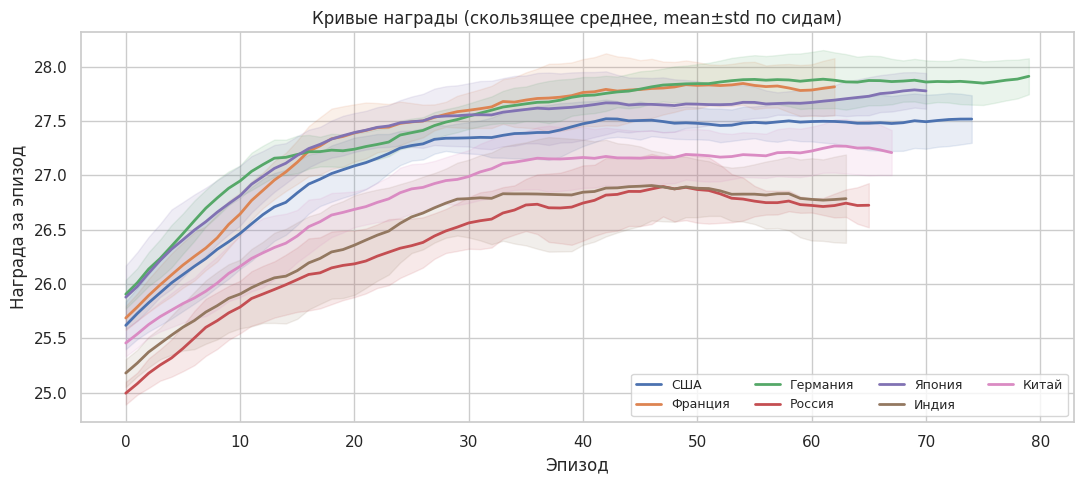

In [19]:
import matplotlib.pyplot as plt
_ = fig_reward_curves(results); plt.show()

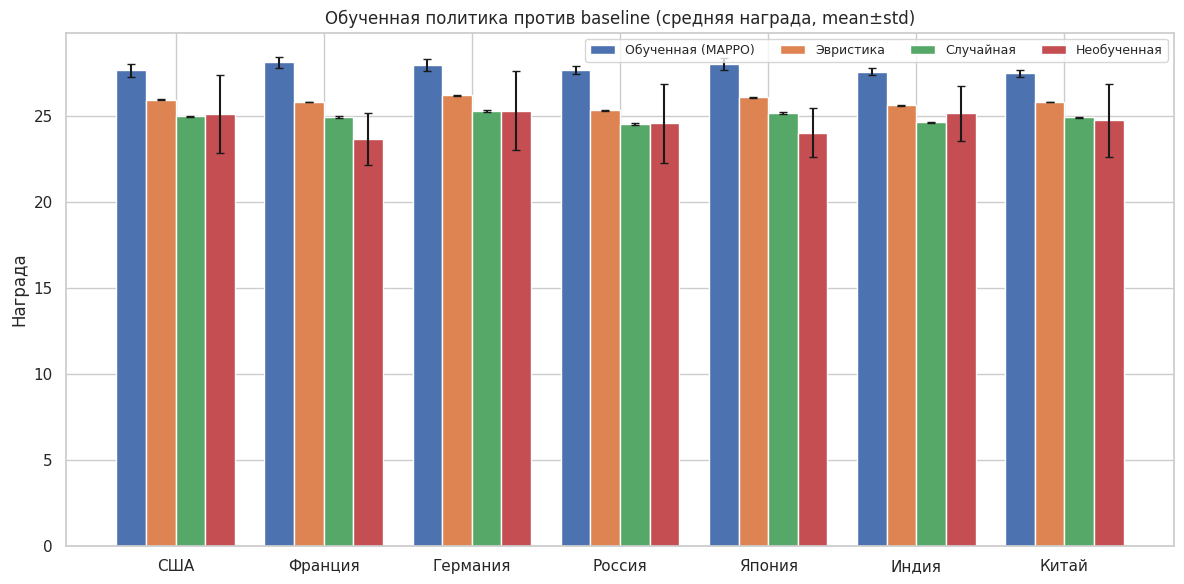

In [20]:
_ = fig_trained_vs_baselines(results); plt.show()

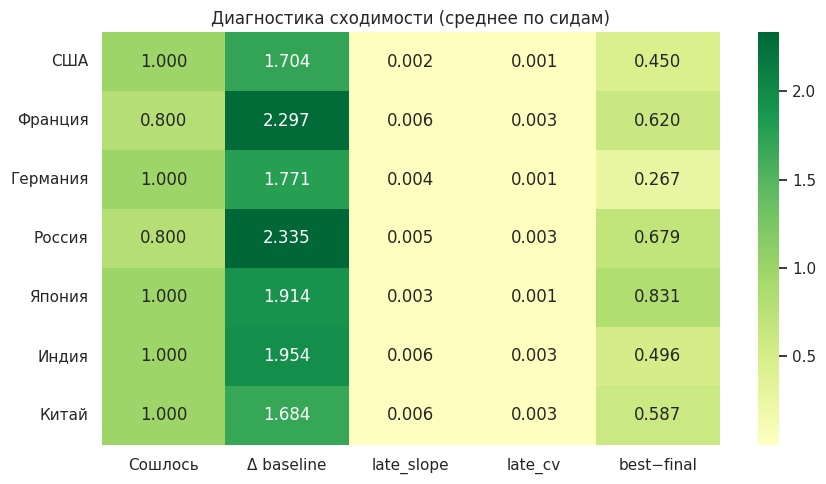

In [21]:
_ = fig_convergence_heatmap(results); plt.show()

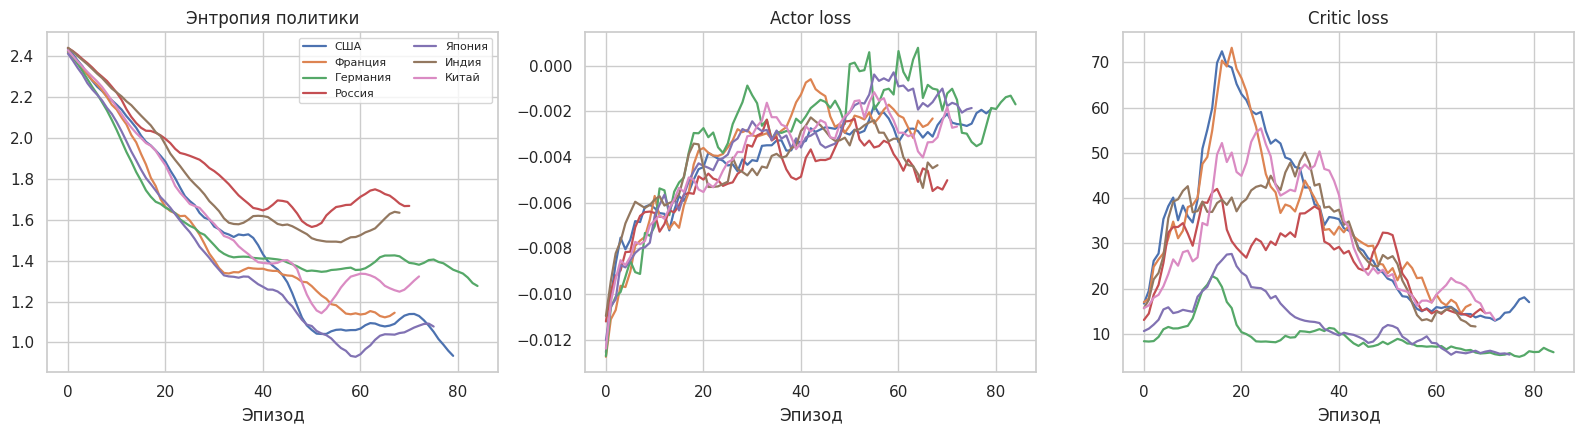

In [22]:
_ = fig_entropy_loss(results); plt.show()

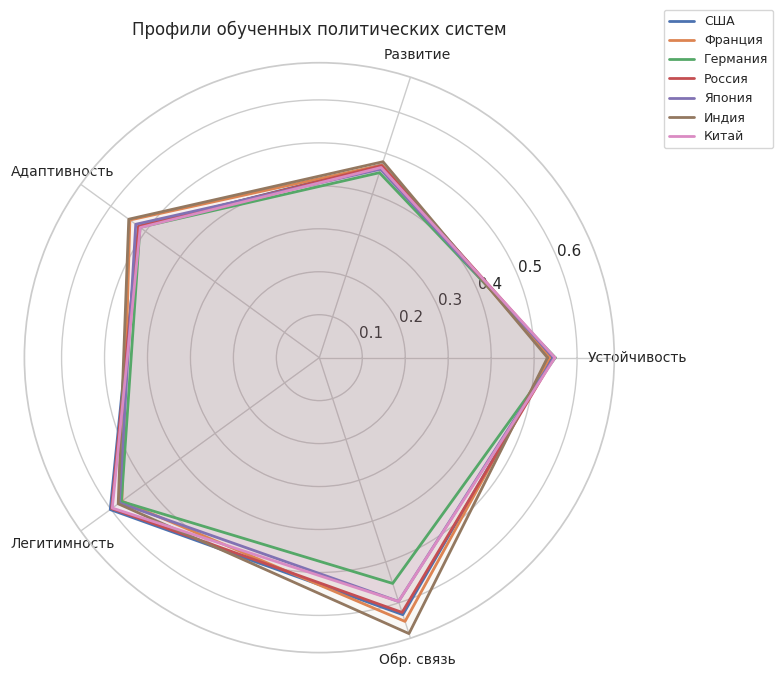

In [23]:
_ = fig_radar(results); plt.show()

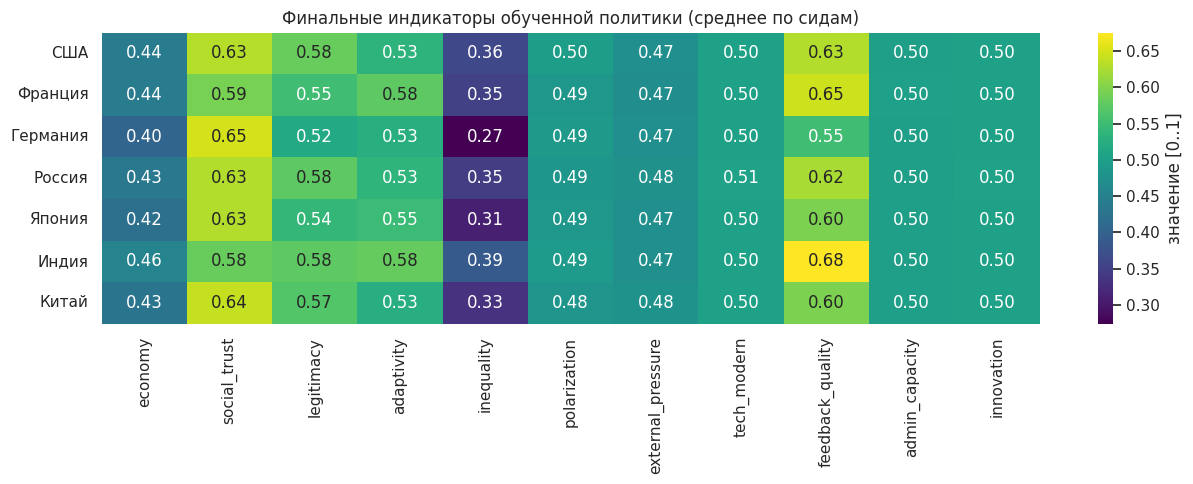

,economy,social_trust,legitimacy,adaptivity,inequality,polarization,external_pressure,tech_modern,feedback_quality,admin_capacity,innovation
США,0.44,0.63,0.58,0.53,0.36,0.50,0.47,0.50,0.63,0.5,0.5
Франция,0.44,0.59,0.55,0.58,0.35,0.49,0.47,0.50,0.65,0.5,0.5
Германия,0.40,0.65,0.52,0.53,0.27,0.49,0.47,0.50,0.55,0.5,0.5
Россия,0.43,0.63,0.58,0.53,0.35,0.49,0.48,0.51,0.62,0.5,0.5
Япония,0.42,0.63,0.54,0.55,0.31,0.49,0.47,0.50,0.60,0.5,0.5
Индия,0.46,0.58,0.58,0.58,0.39,0.49,0.47,0.50,0.68,0.5,0.5
Китай,0.43,0.64,0.57,0.53,0.33,0.48,0.48,0.50,0.60,0.5,0.5


In [24]:
_fig, df_state = fig_final_state_heatmap(results); plt.show()
df_state.round(2)

## 19. Архив результатов и выгрузка

Создаёт папку `results_v2/` (raw json, csv, xlsx, фигуры png, markdown-отчёт, чекпойнты лучших политик, конфиг) и zip-архив. В Colab предлагает скачать; вне Colab печатает путь.

In [25]:
zip_path = build_archive(results, out_dir="results_v2")
print("Архив:", zip_path)

try:
    from google.colab import files  # type: ignore
    files.download(zip_path)
except Exception as e:
    print("Загрузка через Colab недоступна (вероятно, не Colab). Файл сохранён локально:")
    import os
    print(os.path.abspath(zip_path))

Архив: results_v2.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 20. Политологическая интерпретация результатов

- Обученная MAPPO-политика **превосходит** случайную и эвристическую — значит, в синтетической среде существует нетривиальная управленческая стратегия, и агенты её находят.
- Различие профилей стран (radar) отражает разные **целевые функции режимов** (веса награды) и стартовые условия, а не разную механику.
- Штраф за противоречия не даёт «дешёвой» легитимности при высоком неравенстве/поляризации — это приближает модель к политологической реальности.
- Диагностика сходимости (`late_slope ≈ 0`, `stable_plateau`) и `best_vs_final_gap` подтверждают, что оценивается именно стабилизировавшаяся (а через чекпойнт — лучшая) политика.

> Интерпретировать следует **относительные профили и динамику**, а не абсолютные числа: они зависят от сидов и шоков (поэтому приводятся в формате среднего и стандтного отклонения, mean±std).

## 21. Ограничения

1. Синтетические параметры — модель не прогнозирует реальные события.
2. Действия дискретны (12 архетипов); реальная политика богаче.
3. Общий актор на страну — ролевые различия кодируются входом, а не отдельными сетями (компромисс ради скорости 5 сидов).
4. Нет явного канала коммуникации/торга между агентами помимо общего состояния и централизованного критика. Т.е. нет внутреннихх процедур оценки, обратной связи. С их учетом неоходим иерархический MARL - очень дорогая вычислительная задача.
5. Награда нормативна: веса метрик и штрафы за противоречия — заданы по умолчанию. В релаьности награда может варьироваться в зависимости от идеологических приоритетов политичесокго режима.
6. Гомеостаз и мягкие границы — упрощения; архитектуру и стартовые данные эксперимента необходимо калибровать под конкретные исследовательские вопросы.

**Расширения:** непрерывные/иерархические действия, коммуникационный канал (каналы) межлду агентами (COMA/MADDPG-messaging), эндогенные шоки и кризисные сценаррии, межстрановой геополитический контур, обучение весов награды, байесовская оценка неопределённости по сидам.  Средства предоления "взлома функции награды" - reward hacking